In [1]:
!nvidia-smi

Fri Sep  4 18:02:23 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install -q kaggle

In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [5]:
!kaggle datasets download -d ananthu017/emotion-detection-fer

Dataset URL: https://www.kaggle.com/datasets/ananthu017/emotion-detection-fer
License(s): CC0-1.0
100% 65.2M/65.2M [00:02<00:00, 25.3MB/s]



In [6]:
!unzip -q emotion-detection-fer.zip -d emotion_dataset

In [7]:
!find emotion_dataset -maxdepth 2 -type d

emotion_dataset
emotion_dataset/test
emotion_dataset/test/happy
emotion_dataset/test/surprised
emotion_dataset/test/sad
emotion_dataset/test/fearful
emotion_dataset/test/angry
emotion_dataset/test/neutral
emotion_dataset/test/disgusted
emotion_dataset/train
emotion_dataset/train/happy
emotion_dataset/train/surprised
emotion_dataset/train/sad
emotion_dataset/train/fearful
emotion_dataset/train/angry
emotion_dataset/train/neutral
emotion_dataset/train/disgusted


In [8]:
import tensorflow as tf

IMG_SIZE = 48
BATCH_SIZE = 64

train_dir = "/content/emotion_dataset/train"
test_dir = "/content/emotion_dataset/test"

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(train_ds.class_names)

Found 28709 files belonging to 7 classes.
Found 7178 files belonging to 7 classes.
['angry', 'disgusted', 'fearful', 'happy', 'neutral', 'sad', 'surprised']


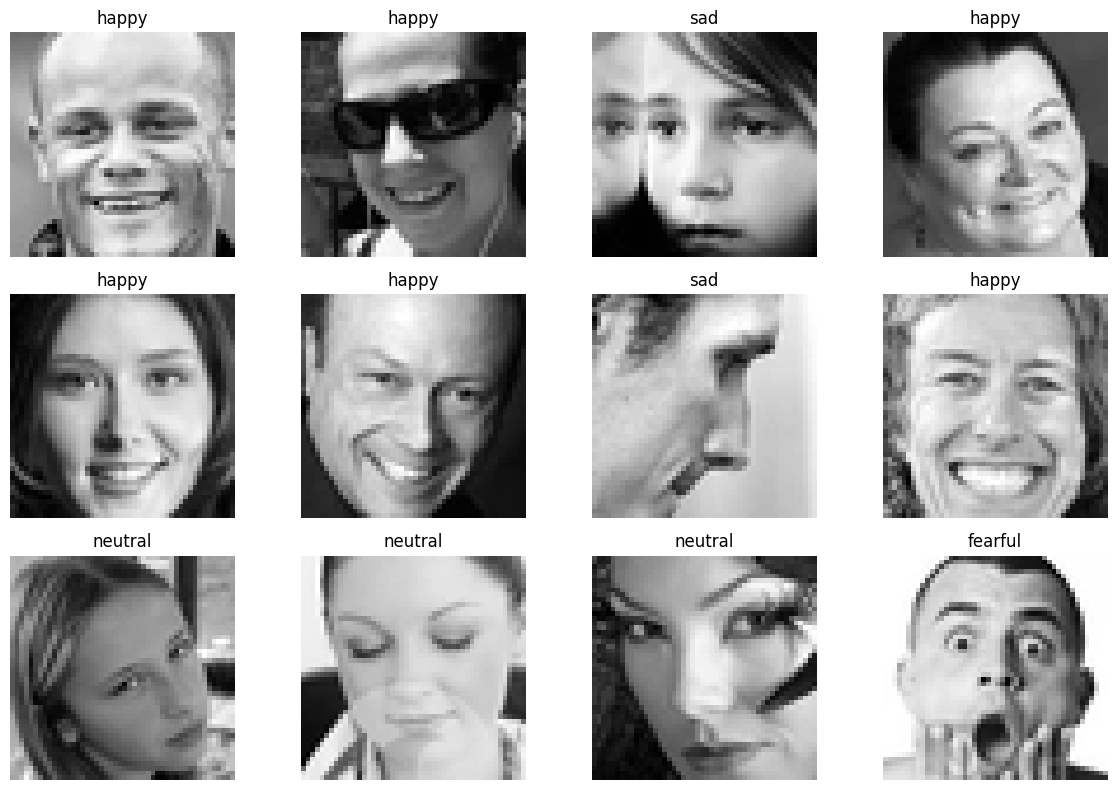

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

for images, labels in train_ds.take(1):
    for i in range(12):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().squeeze(), cmap="gray")
        plt.title(train_ds.class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(48, 48, 1)),

    layers.Conv2D(32, (3,3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(7, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,847 (1.36 MB)

 Trainable params: 355,847 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=30
)

Epoch 1/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - accuracy: 0.2835 - loss: 1.7622 - val_accuracy: 0.4090 - val_loss: 1.5692
Epoch 2/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.4085 - loss: 1.5350 - val_accuracy: 0.4687 - val_loss: 1.4202
Epoch 3/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.4586 - loss: 1.4149 - val_accuracy: 0.4939 - val_loss: 1.3292
Epoch 4/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.4912 - loss: 1.3387 - val_accuracy: 0.5128 - val_loss: 1.2766
Epoch 5/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.5156 - loss: 1.2891 - val_accuracy: 0.5255 - val_loss: 1.2464
Epoch 6/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.5307 - loss: 1.2410 - val_accuracy: 0.5364 - val_loss: 1.2153
Epoch 7/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.5499 - loss: 1.2006 - val_accuracy: 0.5341 - val_loss: 1.2037
Epoch 8/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.5569 - loss: 1.1749 - val_acc

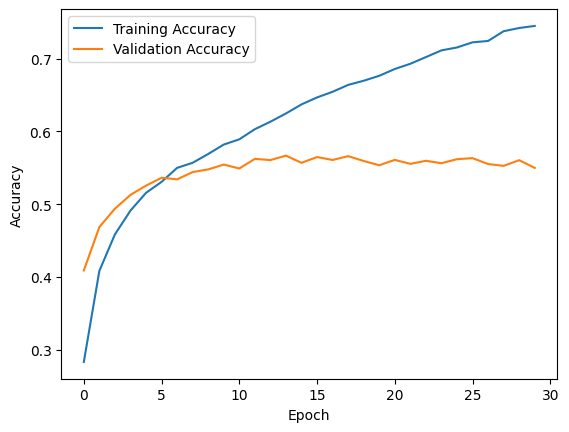

In [12]:
import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [13]:
model.save("/content/emotion_model.keras")